# Detecting Galactic Faraday rotation with LuSEE-Night

**Takeaway.** After discarding the low-depth region where instrumental
leakage lives, a diffuse Faraday signal at the **uniform-slab**
depolarisation floor is detectable at 30 and 50 MHz; at the
**internal-dispersion** floor it is not detectable at any band. The
science case turns on which floor the interstellar medium sets — a
mixed-versus-external-screen geometry question — and not on the
instrument, the analysis basis, or the integration time.

This is the executable companion to
`report/faraday_depth_template/`. It loads the `step5_*.npz` products
and rebuilds every figure by calling `scripts/step5_plots.py`, so the
pictures are the same objects the report uses. It runs in ~40 s and
needs no `data/` artifacts.

**Detection, not localisation.** These are different questions with
different statistics and very different answers. Detection asks whether
there is *any* evidence of Faraday rotation that a systematic cannot
explain; localisation asks whether a feature can be placed on the depth
axis and mapped to Galactic structure. This notebook leads with
detection because localisation (§9) is marginal at best.

In [1]:
import io
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
from IPython.display import Image, Markdown, display

REPO = Path.cwd()
if REPO.name == "notebooks":
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "scripts"))

# common sets JAX_ENABLE_X64=1 before anything pulls jax in, and puts
# src/ on the path.  step5_plots imports it too; importing it here
# first makes the ordering explicit rather than incidental.
import common  # noqa: E402
import step5_detection as sd  # noqa: E402
import step5_plots as sp  # noqa: E402
from common import GEN_DIR  # noqa: E402

from lusee_faraday import dispersion as dsp  # noqa: E402
from lusee_faraday.conventions import lambda_squared  # noqa: E402


def show(fig, pad=0.25, dpi=140):
    """Render a figure to an inline PNG, backend-independently.

    step5_plots selects Agg at import (it is a script module), so the
    usual inline formatter is not registered.  This DISPLAYS rather
    than returning the Image: returning it drops the figure silently
    whenever the call is not the cell's last expression.
    """
    buf = io.BytesIO()
    fig.savefig(
        buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=pad
    )
    sp.plt.close(fig)
    display(Image(data=buf.getvalue()))


def table(rows, header):
    out = ["| " + " | ".join(header) + " |",
           "|" + "|".join(["---"] * len(header)) + "|"]
    out += ["| " + " | ".join(str(c) for c in r) + " |" for r in rows]
    return Markdown("\n".join(out))


def human(n):
    return f"{n / 1e6:.1f} MB" if n >= 1e6 else f"{n / 1e3:.1f} kB"


def small(x):
    """A ratio, without collapsing tiny values to a misleading 0.000."""
    return f"{x:.3f}" if x >= 1e-3 else f"{x:.1e}"


def large(x):
    """A factor, readable when it runs to many digits."""
    return f"{x:.0f}x" if x < 1e4 else f"{x:.1e}x"


PRODUCTS = {
    "template (four-port)": "step5_template.npz",
    "template (two-port)": "step5_template_two_port.npz",
    "sensitivity": "step5_sensitivity.npz",
    "instrument envelope": "step5_envelope.npz",
    "detection": "step5_detection.npz",
    "intuition (figure inputs)": "step5_intuition.npz",
}
missing = [v for v in PRODUCTS.values() if not (GEN_DIR / v).exists()]
if missing:
    raise SystemExit(
        "missing analysis products in generated_data/: "
        + ", ".join(missing)
        + "\nThey are gitignored (regenerable). See section 13."
    )

d = np.load(GEN_DIR / "step5_template.npz")
d2 = np.load(GEN_DIR / "step5_template_two_port.npz")
s = np.load(GEN_DIR / "step5_sensitivity.npz")
env = np.load(GEN_DIR / "step5_envelope.npz")
det = np.load(GEN_DIR / "step5_detection.npz")
q = np.load(GEN_DIR / "step5_intuition.npz")

BANDS = d["bands"]
KS = d["ks"]
K_FID = int(d["k_fiducial_index"]) if "k_fiducial_index" in d.files else 1
CUTS = det["cuts"]
IC0 = int(np.argmin(np.abs(CUTS)))
ICS = int(np.argmin(np.abs(CUTS - 27.5)))

head = subprocess.run(
    ["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True,
).stdout.strip()
branch = subprocess.run(
    ["git", "-C", str(REPO), "rev-parse", "--abbrev-ref", "HEAD"],
    capture_output=True, text=True,
).stdout.strip()

display(Markdown(
    f"**Branch** `{branch}` at `{head}`  |  "
    f"**bands** {', '.join(f'{b:.0f}' for b in BANDS)} MHz  |  "
    f"**fiducial geometry** k = {KS[K_FID]:.0f} (uniform slab)  |  "
    f"**{int(det['lunations'])} lunations**"
))
display(table(
    [(n, f"`{f}`",
      datetime.fromtimestamp((GEN_DIR / f).stat().st_mtime, timezone.utc)
      .strftime("%Y-%m-%d %H:%M UTC"),
      human((GEN_DIR / f).stat().st_size))
     for n, f in PRODUCTS.items()],
    ["product", "file", "written", "size"],
))

**Branch** `faraday-delay-template` at `d471d12`  |  **bands** 30, 50, 10 MHz  |  **fiducial geometry** k = 0 (uniform slab)  |  **24 lunations**

| product | file | written | size |
|---|---|---|---|
| template (four-port) | `step5_template.npz` | 2026-08-24 23:22 UTC | 49.0 MB |
| template (two-port) | `step5_template_two_port.npz` | 2026-08-25 01:05 UTC | 49.0 MB |
| sensitivity | `step5_sensitivity.npz` | 2026-08-25 01:23 UTC | 3.0 kB |
| instrument envelope | `step5_envelope.npz` | 2026-08-21 03:21 UTC | 1.9 kB |
| detection | `step5_detection.npz` | 2026-08-25 01:19 UTC | 4.0 kB |
| intuition (figure inputs) | `step5_intuition.npz` | 2026-09-03 17:50 UTC | 367.0 kB |

## 1. What the audit refuted

The previous diffuse calculation summed the Faraday phasor pixel by
pixel,

$$P(\lambda^2) \;=\; \sum_n w_n\, e^{2 i \phi_n \lambda^2},$$

and read an amplitude off it. The Hutschenreuter map is a *smooth*
reconstruction, so neighbouring nside-512 pixels are close in depth —
a median $|\Delta{\rm RM}|$ of 0.56 rad m$^{-2}$, p90 4.3 — but at
30 MHz ($\lambda^2 \approx 99.9\ \mathrm{m}^2$) that is already ~18
turns of the carrier between a median neighbour pair, and ~160 turns
at 10 MHz. The sum is therefore a **random walk** and carries no sky
information. The Step 2 and Step 4 results live only on the
`audit-2026-08-18` tag.

Its magnitude decays to $1/\sqrt{N_{\rm eff}}$, with
$N_{\rm eff} = (\sum_n |w_n|)^2 / \sum_n |w_n|^2$ — the number of
pixels the weighted sum *actually* averages. The familiar
$1/\sqrt{N_{\rm pix}}$ is the equal-weight special case, which the
next cell illustrates on synthetic depths; the cell after it is the
real sky, where the two differ by an order of magnitude.

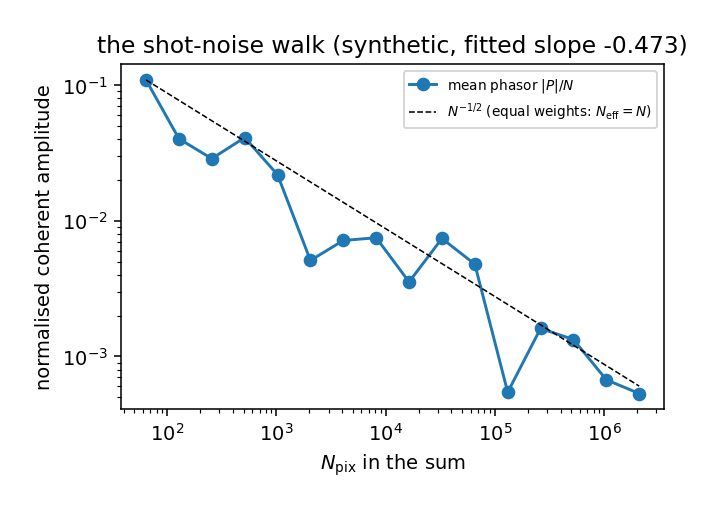

In [2]:
lam2_30 = float(lambda_squared(30.0)[0])
rng = np.random.default_rng(0)
phi_synth = rng.normal(0.0, 100.0, 2 ** 21)
ns = np.array([2 ** k for k in range(6, 22)])
amp = np.array(
    [abs(np.exp(2j * phi_synth[:n] * lam2_30).mean()) for n in ns]
)
slope = np.polyfit(np.log(ns), np.log(amp), 1)[0]

fig, ax = sp.plt.subplots(figsize=(5, 3.2))
ax.loglog(ns, amp, "o-", label="mean phasor $|P|/N$")
ax.loglog(ns, amp[0] * (ns / ns[0]) ** -0.5, "k--", lw=0.8,
          label=r"$N^{-1/2}$ (equal weights: $N_{\rm eff} = N$)")
ax.set(xlabel=r"$N_{\rm pix}$ in the sum",
       ylabel="normalised coherent amplitude",
       title=f"the shot-noise walk (synthetic, fitted slope {slope:.3f})")
ax.legend(fontsize=7)
show(fig)

The real sky is not equal-weight. The beam- and emissivity-weighted
$|w|^2$ is concentrated on the Galactic plane and on a handful of
compact sources, so $N_{\rm eff}$ is one to two percent of the pixels
present and the floor sits **an order of magnitude above**
$1/\sqrt{N_{\rm pix}}$. Getting that wrong makes an estimator lying
exactly on its floor read as one that failed to reach it — which is
why the guide line in the figure below is $N_{\rm eff}^{-1/2}$ and
not $N_{\rm pix}^{-1/2}$.

$1/\sqrt{N_{\rm eff}}$ is an *absolute* prediction with nothing
fitted. A single $\lambda^2$ sample has Rayleigh-distributed $|P|$, so
the measured points scatter about it by construction.

| nside | $N_{\rm pix}$ | $N_{\rm eff}$ | $N_{\rm eff}/N_{\rm pix}$ | floor $N_{\rm eff}^{-1/2}$ | measured | measured / floor |
|---|---|---|---|---|---|---|
| 64 | 49,152 | 1,100 | 2.2% | 0.0302 | 0.0264 | 0.88x |
| 128 | 196,608 | 2,548 | 1.3% | 0.0198 | 0.0239 | 1.21x |
| 256 | 786,432 | 8,210 | 1.0% | 0.0110 | 0.0059 | 0.53x |
| 512 | 3,145,728 | 30,870 | 1.0% | 0.0057 | 0.0075 | 1.31x |

_$N_{\rm eff}$ grows as $N_{\rm pix}^{0.81}$, so the floor falls as $N_{\rm pix}^{-0.40}$ while the measured decay is $N_{\rm pix}^{-0.38}$. Every point lies inside the 16-84% Rayleigh band of a single sample (0.42-1.35x), so this is a zero-parameter match rather than an approximate one._

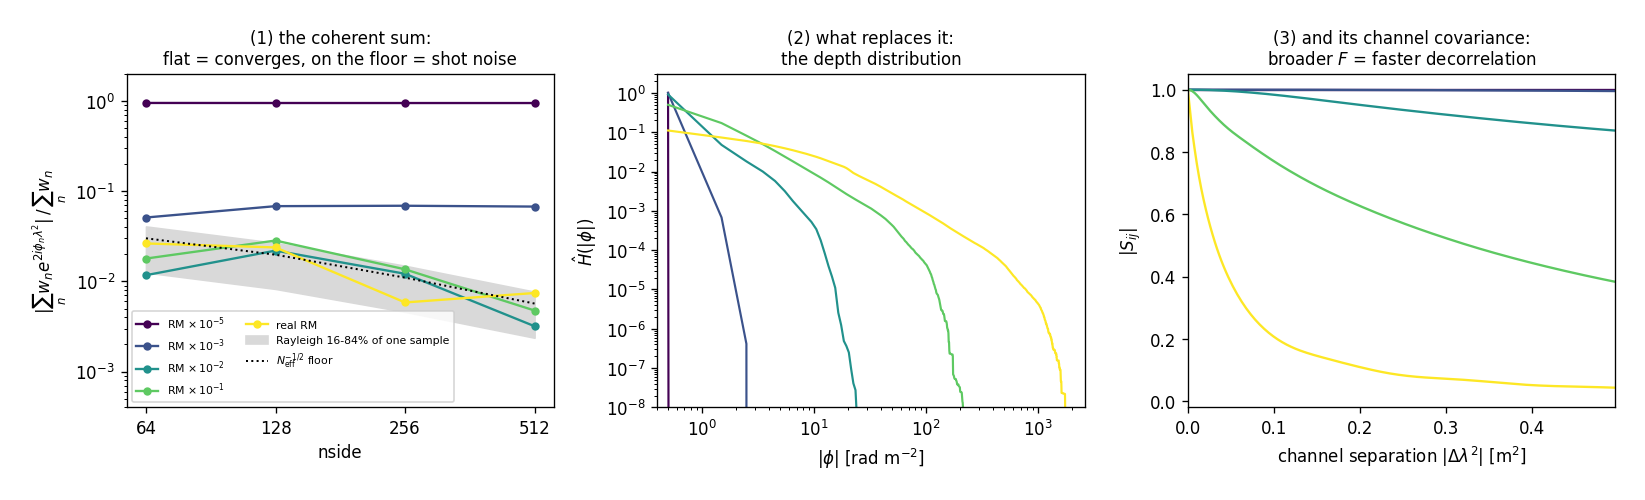

In [3]:
npix = 12.0 * q["nsides"].astype(float) ** 2
neff = q["coherent_n_eff"]
meas = q["coherent_norm"][-1]          # the real RM map, not a scaled one
grow = np.polyfit(np.log(npix), np.log(neff), 1)[0]
pred = np.polyfit(np.log(npix), -0.5 * np.log(neff), 1)[0]
seen = np.polyfit(np.log(npix), np.log(meas), 1)[0]
display(table(
    [(int(n), f"{p:,.0f}", f"{e:,.0f}", f"{100 * e / p:.1f}%",
      f"{1 / np.sqrt(e):.4f}", f"{m:.4f}", f"{m * np.sqrt(e):.2f}x")
     for n, p, e, m in zip(q["nsides"], npix, neff, meas)],
    ["nside", "$N_{\\rm pix}$", "$N_{\\rm eff}$",
     "$N_{\\rm eff}/N_{\\rm pix}$", "floor $N_{\\rm eff}^{-1/2}$",
     "measured", "measured / floor"],
))
display(Markdown(
    f"_$N_{{\\rm eff}}$ grows as $N_{{\\rm pix}}^{{{grow:.2f}}}$, so the "
    f"floor falls as $N_{{\\rm pix}}^{{{pred:.2f}}}$ while the measured "
    f"decay is $N_{{\\rm pix}}^{{{seen:.2f}}}$. Every point lies inside "
    f"the 16-84% Rayleigh band of a single sample (0.42-1.35x), so this "
    f"is a zero-parameter match rather than an approximate one._"
))
show(sp.fig_bridge(q), dpi=120)

## 2. The fix: bin in depth first, transform second

Accumulate $|w_n|^2$ into depth bins to form $F(\phi)$, then transform:

$$P(\lambda^2) \;=\; \int F(\phi)\, e^{2 i \phi \lambda^2}\, d\phi .$$

Binning is a histogram operation, and a histogram's **shape** is stable
under refinement. The shot noise does not vanish — it is confined to the
normalisation, which is exactly the quantity this work declines to
predict.

*Pinned by* `test_gate1_shape_invariance_under_refinement` (CDF
distances 2e-5 to 1.9e-4 across nside 256–2048 against a 1e-2
tolerance, while the coherent observable collapses 134x) and
`test_depth_power_equals_the_weighted_depth_distribution` (the
incoherent-limit identity, 1.069).

## 3. What "beam-weighted" means

Every pixel enters weighted by $|w|^2$, the LST- and pair-averaged
Faraday response, combining **both** Faraday branches as
$\sqrt{\tfrac12(|K_Q|^2+|K_U|^2)}$ — using one branch alone would make
every number below depend on the arbitrary $Q$/$U$ basis orientation.

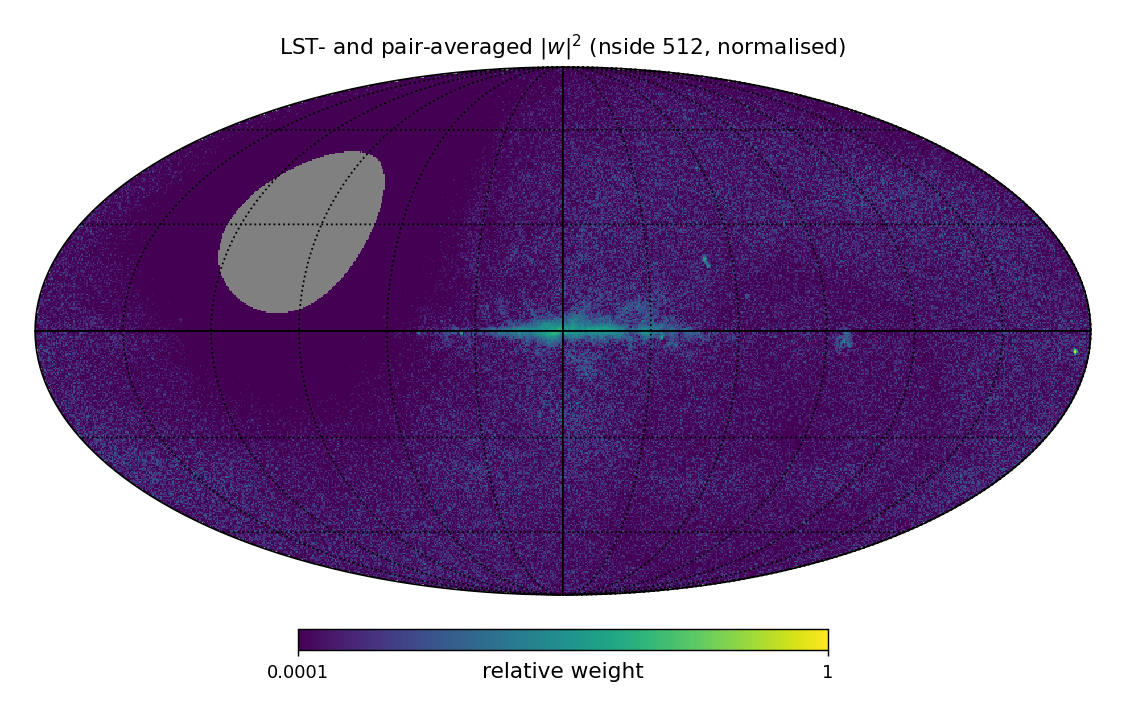

_4.2% of the sky (grey) is never above the horizon and carries exactly zero weight. The Galactic plane dominates, which is why the plane taper in §8 moves the roll-off so far._

In [4]:
w2 = d["w2_mean"]
show(sp.fig_weight_map(d), dpi=130)
display(Markdown(
    f"_{100 * (w2 <= 0).sum() / w2.size:.1f}% of the sky (grey) is never "
    f"above the horizon and carries exactly zero weight. The Galactic "
    f"plane dominates, which is why the plane taper in §8 moves the "
    f"roll-off so far._"
))

## 4. One signal, two bases: Faraday depth and delay

Faraday depth $\phi$ is conjugate to $\lambda^2$; delay $\tau$ is
conjugate to $\nu$. They are **not** the same axis — the refuted Step 4
used $\tau$, in milliseconds — but for detection they carry the same
information, and the argument against the delay basis has been
overstated.

$$\tau_{\rm FD}(\phi,\nu) \;=\; \frac{2\phi c^2}{\pi \nu^3}$$

is *monotonic* in $\phi$, so a cut in one is exactly a cut in the other
and retains identically the same power. The cell below measures the two
things that could break that equivalence: the chirp (because
$\tau_{\rm FD}\propto\nu^{-3}$ drifts across the band) and aliasing.

| band | template extent (res elts) | chirp smear | smear / extent | aliasing wall (rad/m²) | aliased / kept signal |
|---|---|---|---|---|---|
| 30 MHz | 386 | 7.7 | **2.0%** | 604 | 1.8% |
| 50 MHz | 83 | 1.0 | **1.2%** | 2796 | 0.0% |
| 10 MHz | 10425 | 625.5 | **6.0%** | 22 | 115.1% |

_**Our signal is not a peak.** It spans hundreds of resolution elements, so smearing it by 1–2% of its own width changes nothing; the chirp destroys information only for a *narrow* feature, i.e. localisation. 10 MHz fails on **aliasing**, not the chirp — and it was already out on other grounds. The aliasing wall coincides with the instrument's own depth horizon (§6) to 0.1% at all three bands: measured, and not something this work explains._

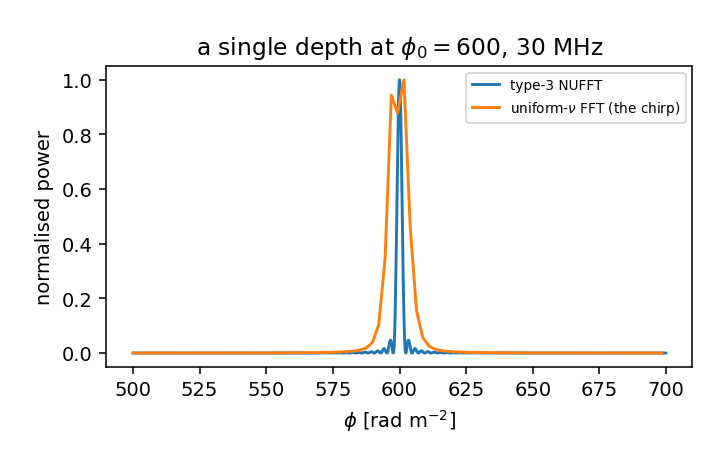

In [5]:
C = 299792458.0
rows = []
for ib, band in enumerate(BANDS):
    _, bins, _ = dsp.zoom_bin_matrix(band)
    dt = 1.0 / ((bins.max() - bins.min()) * 1e6)
    nyq = 1.0 / (2 * np.median(np.diff(np.sort(bins))) * 1e6)
    phi_alias = nyq * np.pi * (band * 1e6) ** 3 / (2 * C ** 2)
    H = d["H"][ib, K_FID]
    ext = sd.delay_of_depth(2442.0, band) / dt
    chirp = sd.delay_of_depth(2442.0, band) * 3 * 0.2e6 / (band * 1e6) / dt
    al = H[d["phi"] > phi_alias].sum() / H.sum()
    keep = H[d["phi"] >= CUTS[ICS]].sum() / H.sum()
    rows.append((f"{band:.0f} MHz", f"{ext:.0f}", f"{chirp:.1f}",
                 f"**{100 * chirp / ext:.1f}%**", f"{phi_alias:.0f}",
                 f"{100 * al / keep:.1f}%"))
display(table(rows, ["band", "template extent (res elts)",
                     "chirp smear", "smear / extent",
                     "aliasing wall (rad/m²)", "aliased / kept signal"]))
display(Markdown(
    "_**Our signal is not a peak.** It spans hundreds of resolution "
    "elements, so smearing it by 1–2% of its own width changes nothing; "
    "the chirp destroys information only for a *narrow* feature, i.e. "
    "localisation. 10 MHz fails on **aliasing**, not the chirp — and it "
    "was already out on other grounds. The aliasing wall coincides with "
    "the instrument's own depth horizon (§6) to 0.1% at all three bands: "
    "measured, and not something this work explains._"
))
show(sp.fig_chirp_coherence())

## 5. Faraday resolution

Set by the $\lambda^2$ span the zoom bins cover — 192 centres spanning
74.6 kHz. `dispersion.rmsf` builds the point-spread function from
luseepy's **true** bin responses, cheap enough to recompute here.

Two conventions must travel with any width: `rmsf` returns **power**,
so a width read off it is a power FWHM, while the conventional
RM-synthesis resolution is an **amplitude** FWHM, wider by $1/0.734$.
Both columns below are measured independently.

In [6]:
def fwhm(x, y, level):
    y = np.asarray(y, float) / np.max(y)
    i = int(np.argmax(y))

    def cross(step):
        j = i
        while 0 <= j + step < y.size and y[j + step] >= level:
            j += step
        x0, x1, y0, y1 = x[j], x[j + step], y[j], y[j + step]
        return x0 + (level - y0) * (x1 - x0) / (y1 - y0)

    return cross(+1) - cross(-1)


t0, rows, RES = time.time(), [], {}
for band, half in ((30.0, 40.0), (50.0, 150.0), (10.0, 2.0)):
    fine, bins, W = dsp.zoom_bin_matrix(band)
    po = np.linspace(-half, half, 80001)
    p = dsp.rmsf(0.0, fine, W, bins, po)
    dl2 = np.ptp(np.asarray(lambda_squared(bins), float))
    RES[band] = fwhm(po, p, 0.25)
    rows.append((f"{band:.0f} MHz", f"{fwhm(po, p, 0.5):.3f}",
                 f"**{RES[band]:.3f}**", f"{2 * 1.8955 / dl2:.3f}"))
display(table(rows, ["band", "power FWHM", "amplitude FWHM",
                     "ideal top-hat, same span"]))
display(Markdown(
    f"_rad/m², computed live in {time.time() - t0:.1f} s. The measured "
    f"response sits 0.5% BELOW the ideal top-hat — the (n-1)/n "
    f"correction for summing 192 discrete samples — so **the real bin "
    f"responses do not broaden the PSF at all**. They attenuate; that "
    f"is §6._"
))

| band | power FWHM | amplitude FWHM | ideal top-hat, same span |
|---|---|---|---|
| 30 MHz | 5.574 | **7.592** | 7.632 |
| 50 MHz | 25.805 | **35.150** | 35.334 |
| 10 MHz | 0.206 | **0.281** | 0.283 |

_rad/m², computed live in 0.5 s. The measured response sits 0.5% BELOW the ideal top-hat — the (n-1)/n correction for summing 192 discrete samples — so **the real bin responses do not broaden the PSF at all**. They attenuate; that is §6._

## 6. Channel width as a depth horizon

A spectrometer bin is a window in $\nu$, hence a multiplicative
envelope in depth. The 50% depths, against the beam-weighted sky:

| band | parent horizon | zoom horizon |
|---|---|---|
| 50 MHz | 58.03 | 2796.9 |
| 30 MHz | 12.54 | 604.1 |
| 10 MHz | 0.46 | 22.4 |

| beam-weighted sky RM percentile | rad/m² |
|---|---|
| p50 | 23.4 |
| p90 | 185.7 |
| p99 | 776.1 |
| p99.9 | 1283.0 |
| map max | 2442.1 |

**No parent bin reaches the knee** (0.46–58.0 against 83.3–89.6 rad/m²), so the zoom mode is a requirement, not an enhancement. Only 50 MHz's zoom horizon clears the map maximum.

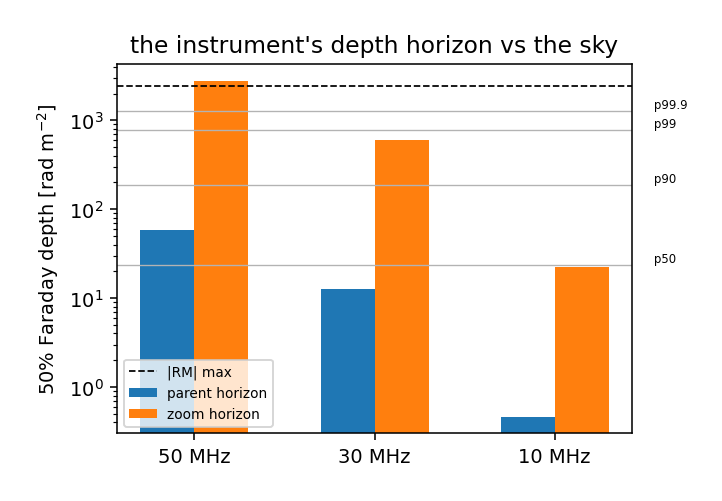

In [7]:
display(table(
    [(f"{b:.0f} MHz", f"{env['parent_horizon'][i]:.2f}",
      f"{env['zoom_horizon'][i]:.1f}")
     for i, b in enumerate(env["bands"])],
    ["band", "parent horizon", "zoom horizon"],
))
display(table(
    [(f"p{q:g}", f"{v:.1f}") for q, v in
     zip(env["percentile_qs"], env["percentiles"])]
    + [("map max", f"{float(env['rm_max']):.1f}")],
    ["beam-weighted sky RM percentile", "rad/m²"],
))
knees = d["knee"][:, K_FID]
display(Markdown(
    f"**No parent bin reaches the knee** "
    f"({env['parent_horizon'].min():.2f}–"
    f"{env['parent_horizon'].max():.1f} against "
    f"{knees.min():.1f}–{knees.max():.1f} rad/m²), so the zoom mode is a "
    f"requirement, not an enhancement. Only 50 MHz's zoom horizon clears "
    f"the map maximum."
))
show(sp.fig_envelope(env))

## 7. Detection SNR against the systematics cut — the result

Instrumental $I\!\to\!Q,U$ leakage passes through a frozen beam, so it
is spectrally smooth and sits at $\phi \approx 0$ (equivalently
$\tau \approx 0$). A statistic integrating all depths is degenerate
with it. **The cut is what breaks the degeneracy.** Its position comes
from the window budget: through a four-term Blackman–Harris window a
$\phi\approx0$ foreground at $|P|/I = 0.15$ leaks $\le 10^{-6}$ of
Stokes $I$ beyond $\phi = 27.5$ rad/m².

For a cut retaining power fraction $f$, the detectable quantity is
$A_{\rm bracket}\sqrt f$ — $\sqrt f$ not $f$, since $f$ is a fraction of
**power** and the bracket an **amplitude** — against a threshold
computed on the **truncated** template. That last point matters: a
statistic looking only above the cut has only the truncated shape to
match against, and its threshold is 28–35% higher. An earlier version
of this work compared a truncated signal against a full-template
threshold.

| cut φ ≥ | keeps | 30 MHz slab | 30 MHz disp | 50 MHz slab | 50 MHz disp | 10 MHz slab | 10 MHz disp |
|---|---|---|---|---|---|---|---|
| no cut | 100% | **28.5** | 0.035 | **102.1** | 0.352 | **2.6** | 3.4e-04 |
| ≥ 5 | 66% | **21.8** | 0.027 | **74.5** | 0.257 | **2.1** | 2.8e-04 |
| ≥ 10 | 50% | **17.5** | 0.021 | **62.8** | 0.216 | **1.9** | 2.5e-04 |
| ≥ 27.5 | 27% | **11.5** | 0.014 | **44.6** | 0.154 | **1.2** | 1.6e-04 |
| ≥ 50 | 17% | **8.4** | 0.010 | **30.5** | 0.105 | 0.93 | 1.2e-04 |
| ≥ 100 | 9% | **6.1** | 0.007 | **20.9** | 0.072 | 0.66 | 8.6e-05 |
| ≥ 200 | 4% | **4.4** | 0.005 | **14.0** | 0.048 | 0.44 | 5.8e-05 |
| ≥ 400 | 1% | **2.9** | 0.004 | **8.6** | 0.030 | 0.26 | 3.4e-05 |

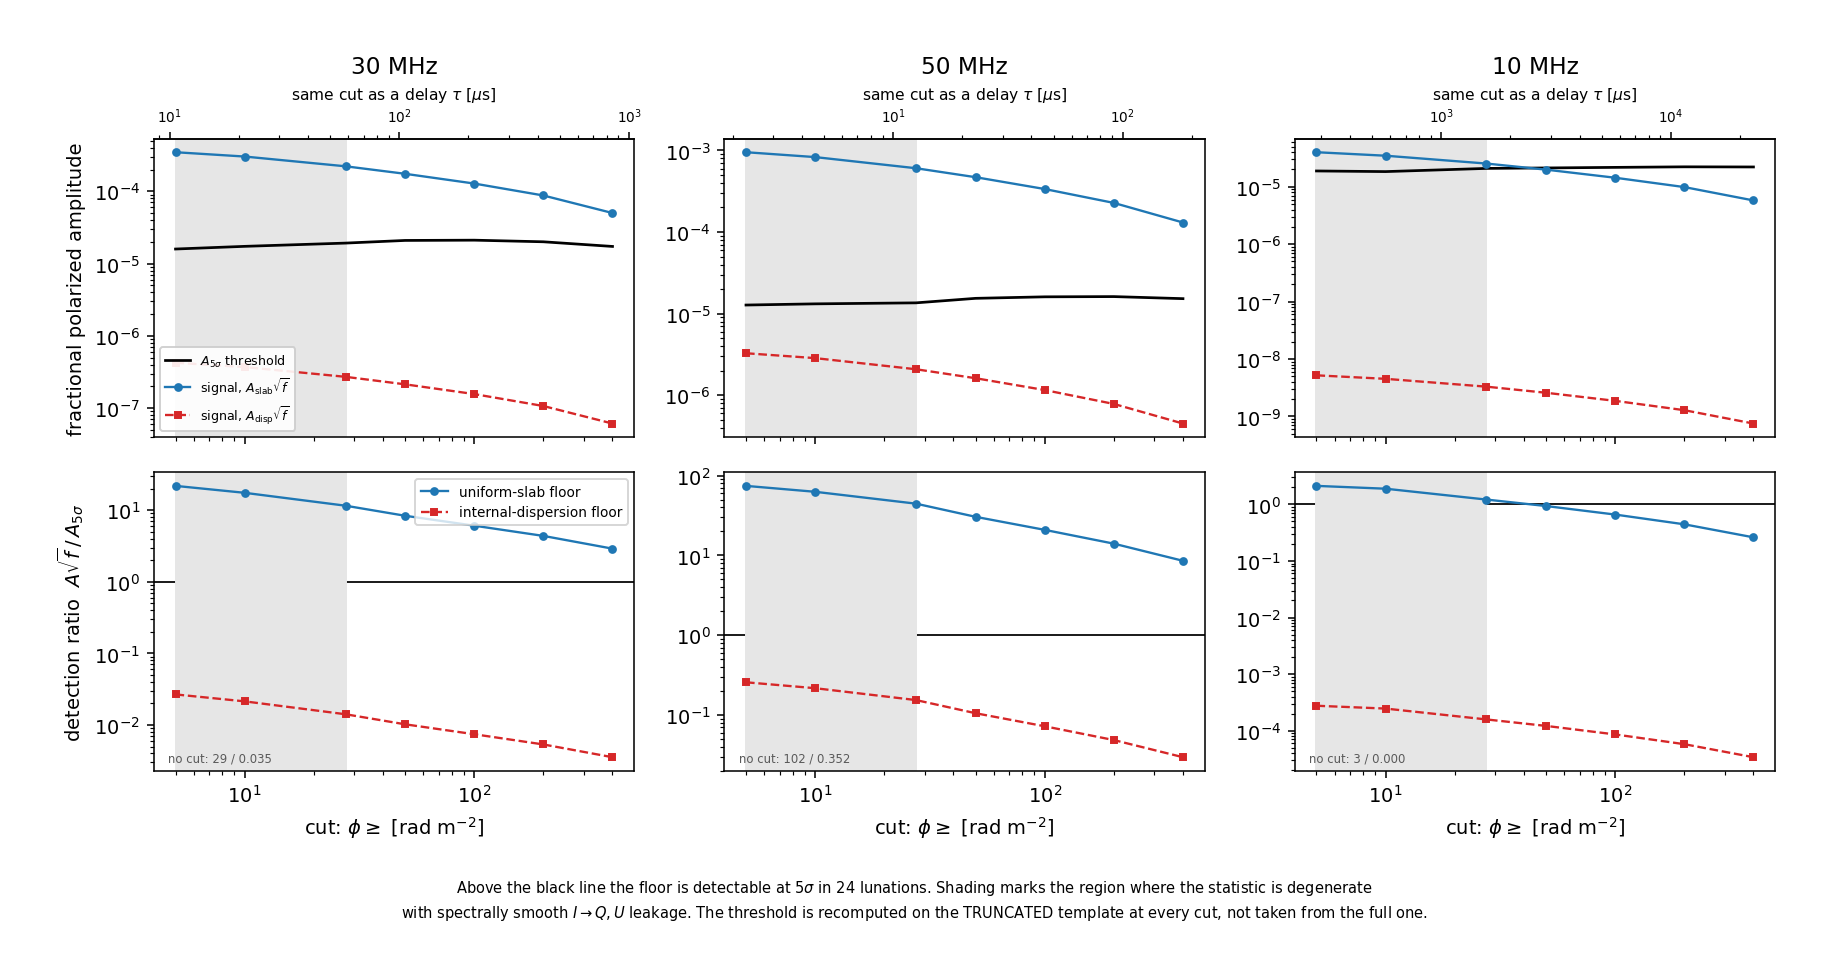

In [8]:
rows = []
for ic, cut in enumerate(CUTS):
    if det["power_fraction"][:, ic].max() <= 0:
        continue
    cells = ["no cut" if cut == 0 else f"≥ {cut:g}",
             f"{100 * det['power_fraction'][0, ic]:.0f}%"]
    for ib in range(len(BANDS)):
        r = det["ratio_slab"][ib, ic]
        cells += [f"**{r:.1f}**" if r > 1 else f"{r:.2f}",
                  small(det["ratio_dispersion"][ib, ic])]
    rows.append(tuple(cells))
display(table(rows, ["cut φ ≥", "keeps"] + [
    f"{b:.0f} MHz {w}" for b in BANDS for w in ("slab", "disp")]))
show(sp.fig_detection(det), pad=0.4)

At the systematics-safe cut:

- **At the uniform-slab floor the signal is detectable** at 30 and
  50 MHz, with margin.
- **At the internal-dispersion floor it is not**, at any band — 50 MHz
  comes closest.
- **The cut is cheap** — a factor of about two in sensitivity, because
  the truncated template still spans most of the axis.

The gate is therefore decided by which depolarisation floor the medium
sets. Both floors are *power laws* only because the geometry is
**mixed**: for an external screen Burn's law gives
$e^{-2\sigma^2\lambda^4}$, whose exponent at 30 MHz is
$\approx 1.9 \times 10^6$ — not a small number but zero. That
conversion is the difference between a detectable signal and no signal
at all.

In [9]:
rows = []
for ib, band in enumerate(BANDS):
    for tag, ic in (("no cut", IC0), (f"φ ≥ {CUTS[ICS]:g}", ICS)):
        gap = 1.0 / det["ratio_dispersion"][ib, ic]
        rows.append((f"{band:.0f} MHz", tag, large(gap), large(gap ** 2)))
display(table(rows, ["band", "cut", "dispersion-floor gap",
                     "observing time to close"]))
display(Markdown(
    "_With `n_lst` saturated by 24 lunations the threshold falls as "
    "`n^-1/2`, so closing a gap costs its **square**. Integration is a "
    "weak lever, but at 50 MHz it is not the absurd one an earlier "
    "version of this work reported — that number was for *localisation* "
    "at 30 MHz, quoted as if it were the detection verdict._"
))

| band | cut | dispersion-floor gap | observing time to close |
|---|---|---|---|
| 30 MHz | no cut | 29x | 822x |
| 30 MHz | φ ≥ 27.5 | 71x | 5012x |
| 50 MHz | no cut | 3x | 8x |
| 50 MHz | φ ≥ 27.5 | 7x | 42x |
| 10 MHz | no cut | 2985x | 8.9e+06x |
| 10 MHz | φ ≥ 27.5 | 6324x | 4.0e+07x |

_With `n_lst` saturated by 24 lunations the threshold falls as `n^-1/2`, so closing a gap costs its **square**. Integration is a weak lever, but at 50 MHz it is not the absurd one an earlier version of this work reported — that number was for *localisation* at 30 MHz, quoted as if it were the detection verdict._

## 8. The template, and how robust its shape is

This is what the matched filter matches against. The roll-off statistic
is the **90%-mass quantile** of the folded template — a CDF quantile,
not a half-power crossing, which would pin to the narrow spike the
$k=0$ slab piles up at the origin.

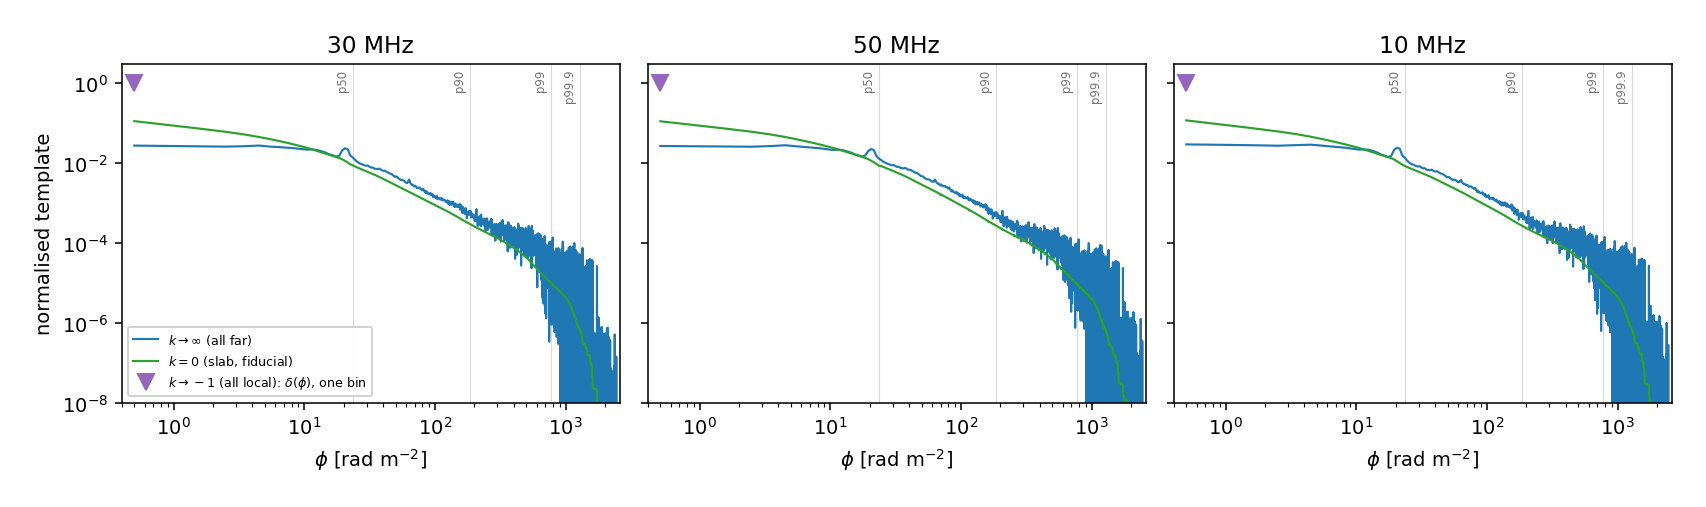

| band | knee (k=0) | plane-tapered | taper factor | two-port knee | arm swap |
|---|---|---|---|---|---|
| 30 MHz | 89.62 | 17.95 | 4.99x | 88.99 | -0.7% |
| 50 MHz | 83.32 | 19.26 | 4.33x | 102.99 | +23.6% |
| 10 MHz | 83.91 | 18.03 | 4.66x | 94.09 | +12.1% |

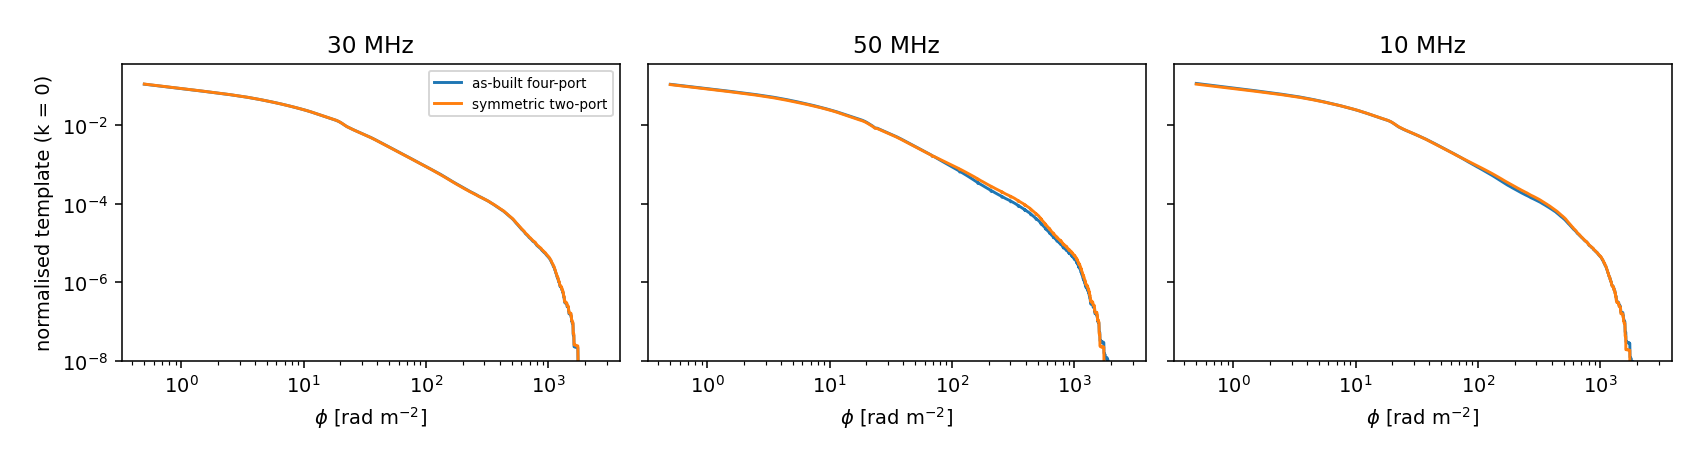

In [10]:
show(sp.fig_template_family(d))
kn, kt = d["knee"][:, K_FID], d["knee_taper"][:, K_FID]
k2 = d2["knee"][:, K_FID]
display(table(
    [(f"{b:.0f} MHz", f"{kn[i]:.2f}", f"{kt[i]:.2f}",
      f"{kn[i] / kt[i]:.2f}x", f"{k2[i]:.2f}",
      f"{100 * (k2[i] - kn[i]) / kn[i]:+.1f}%")
     for i, b in enumerate(BANDS)],
    ["band", "knee (k=0)", "plane-tapered", "taper factor",
     "two-port knee", "arm swap"],
))
show(sp.fig_two_arm(d, d2))

The plane taper moves the knee by a factor 4–5, so **the roll-off is
carried by the Galactic plane**. That is the *unfavourable* branch:
long in-plane paths are where $B_\parallel$ reverses and the linear
$\phi(f)$ ansatz is weakest, so **the amplitude bracket must be read as
wider, not narrower**. The arm swap moves it by under 1% at 30 MHz, the
band that owns the knee.

## 9. Localisation: the tail gate

Localisation needs power above the bulk of the sky's depth
distribution. The tail fraction — template power above the fixed
beam-weighted p99 — peaks at Galactic Centre transit and falls to
~1e-6 away from it.

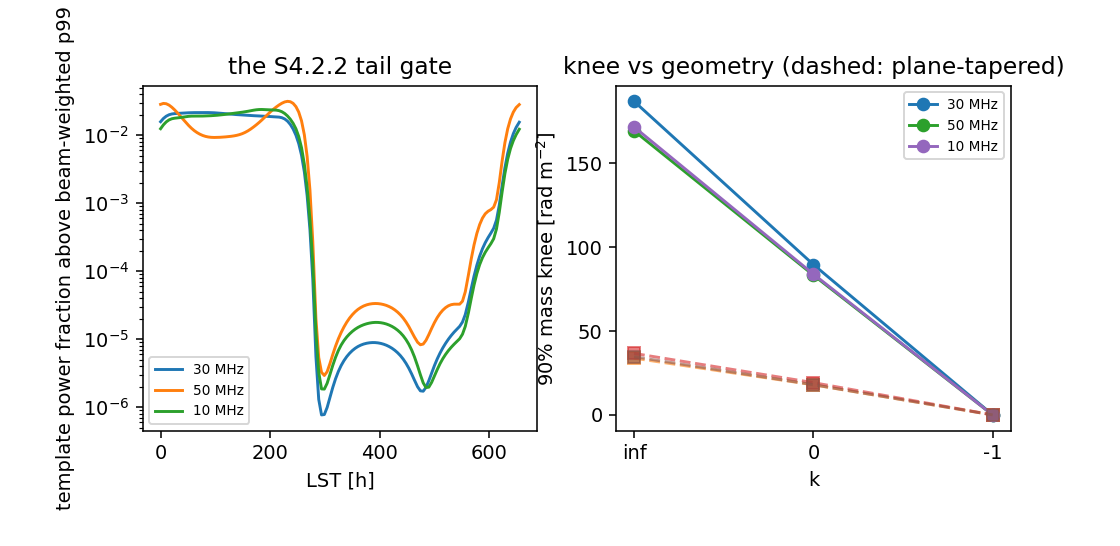

| band | tail power fraction | threshold on the tail | ratio at the slab floor |
|---|---|---|---|
| 30 MHz | 0.47% | 1.81e-05 | 1.62 |
| 50 MHz | 0.65% | 1.38e-05 | 6.83 |
| 10 MHz | 0.54% | 2.17e-05 | 0.17 |

_LST-resolved (transit). Done consistently — the transit power fraction against a threshold computed on the transit template restricted to the same cut. Localisation is marginal where detection has margin, which is why detection is the deliverable and localisation the stretch goal._

In [11]:
show(sp.fig_knee_tail(d), pad=0.4)
src = ("LST-resolved (transit)" if bool(det["lst_resolved_tail"])
       else "LST-averaged approximation")
display(table(
    [(f"{b:.0f} MHz", f"{100 * det['tail_corrected'][i, 0]:.2f}%",
      f"{det['tail_corrected'][i, 1]:.3g}",
      f"{det['tail_corrected'][i, 2]:.2f}")
     for i, b in enumerate(BANDS)],
    ["band", "tail power fraction", "threshold on the tail",
     "ratio at the slab floor"],
))
display(Markdown(
    f"_{src}. Done consistently — the transit power fraction against a "
    f"threshold computed on the transit template restricted to the same "
    f"cut. Localisation is marginal where detection has margin, which is "
    f"why detection is the deliverable and localisation the stretch "
    f"goal._"
))

## 10. What this map cannot decide

**(a) The bracket's upper end.** `coherence_angle` clamps at the lower
edge of its search grid at every band and in both arms, and the clamp
*overstates*. Widening the grid cannot fix it: the root sits roughly
three decades below `faraday2020v2`'s own nside-512 pixel scale, so a
wider grid would extrapolate $D \propto \theta^2$ rather than measure.
The extrapolation *inverts* the bracket, which is itself the proof it
is not quotable. **Not determinable from this map** — never quote it as
~1e-2. Neither usable floor contains $\theta_c$.

**(b) Sky domination at 50 MHz.** `T_sys/T_sky` below is
$1 + T_{\rm loading}/T_{\rm sky}$ and nothing more — the chain carries
no amplifier noise, and `t_sky` is an all-sky mean rather than a
beam-weighted antenna temperature. A genuine **lower bound**, not a
computed check.

In [12]:
display(table(
    [(f"{b:.0f} MHz", f"{np.degrees(float(d['theta_c'][i])):.3f}°",
      "**clamped**" if bool(d["theta_c_clamped"][i]) else "measured",
      f"{d['bracket'][i, 0]:.2g}", f"{d['bracket'][i, 1]:.2g}",
      f"{d['bracket'][i, 2]:.2g}", f"{s['tsys_over_tsky'][i]:.4f}")
     for i, b in enumerate(BANDS)],
    ["band", "theta_c", "status", "upper (unusable)", "lower_slab",
     "lower_dispersion", "T_sys/T_sky"],
))
display(Markdown(
    f"_theta_c is identical across bands at the grid edge — the "
    f"signature of a clamp, not a measurement. Loading is a "
    f"≤{100 * (s['tsys_over_tsky'].max() - 1):.1f}% correction; "
    f"amplifier noise is the open term._"
))

| band | theta_c | status | upper (unusable) | lower_slab | lower_dispersion | T_sys/T_sky |
|---|---|---|---|---|---|---|
| 30 MHz | 0.200° | **clamped** | 0.0099 | 0.00043 | 5.2e-07 | 1.0044 |
| 50 MHz | 0.200° | **clamped** | 0.009 | 0.0012 | 4e-06 | 1.0170 |
| 10 MHz | 0.200° | **clamped** | 0.011 | 5e-05 | 6.4e-09 | 1.0006 |

_theta_c is identical across bands at the grid edge — the signature of a clamp, not a measurement. Loading is a ≤1.7% correction; amplifier noise is the open term._

## 11. Reading the bracket backwards

The bracket's two floors are not two guesses at one number — they are
two different **spectra**. $A_{\rm slab} \propto \nu^2$ while
$A_{\rm disp} \propto \nu^4$, so a **band-to-band amplitude ratio**
separates them with no absolute scale and no assumed intrinsic
polarization fraction $p_0$. That converts the bracket's width from a
weakness into a measurement — a *required* one. It enters no verdict
here, and Section 7's table is unchanged by it.

| band pair | slab ratio | dispersion ratio | statistics contribute | gain known to (5σ) | (3σ) |
|---|---|---|---|---|---|
| 50/30 | 2.738 (-1.4% off $\nu^2$) | 7.716 (+0.00% off $\nu^4$) | 1.8% | **1.23x** | 1.41x |
| 30/10 | 8.619 (-4.2% off $\nu^2$) | 81.000 (+0.00% off $\nu^4$) | 16.6% | **1.52x** | 2.08x |

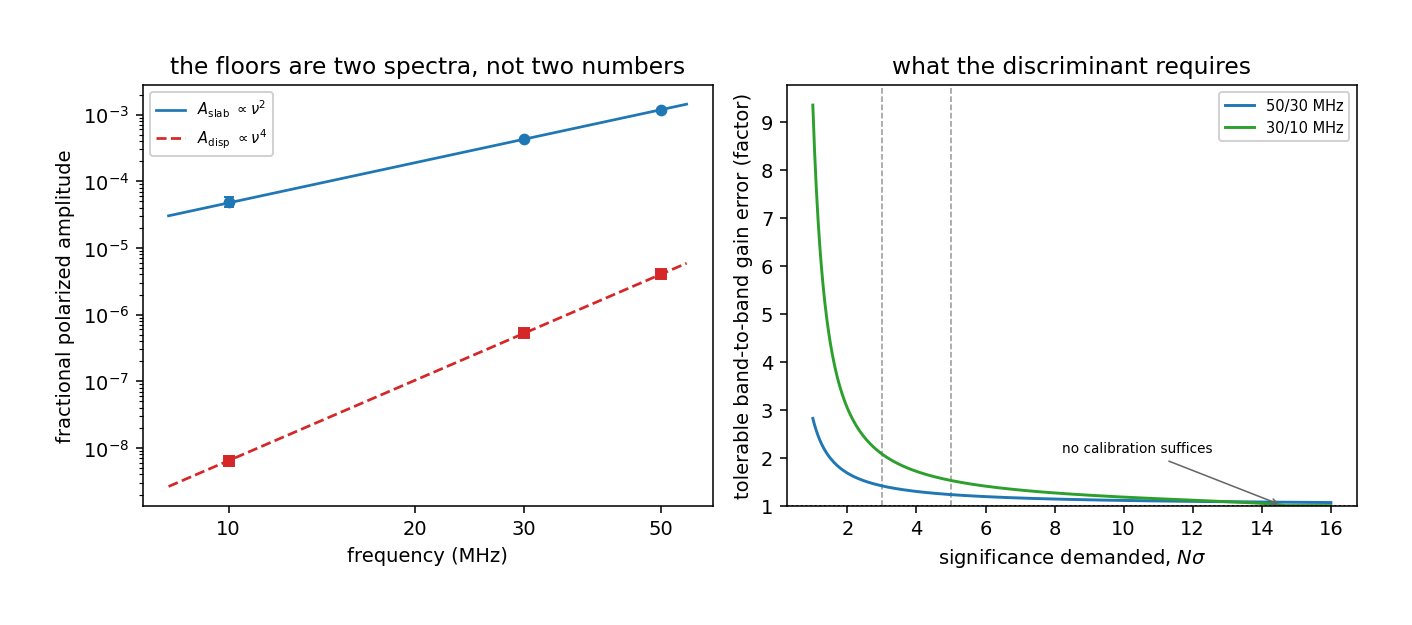

In [13]:
rows = []
for ilo, ihi, pair in ((0, 1, "50/30"), (2, 0, "30/10")):
    blo = {"lower_slab": float(d["bracket"][ilo, 1]),
           "lower_dispersion": float(d["bracket"][ilo, 2])}
    bhi = {"lower_slab": float(d["bracket"][ihi, 1]),
           "lower_dispersion": float(d["bracket"][ihi, 2])}
    # SNR at the SLAB floor: the branch where the slope exists is the
    # branch where a detection exists to take a ratio of.
    snr_lo = 5.0 * float(det["ratio_slab"][ilo, ICS])
    snr_hi = 5.0 * float(det["ratio_slab"][ihi, ICS])
    r = {n: dsp.slope_requirement(blo, bhi, snr_lo, snr_hi, n_sigma=n)
         for n in (3.0, 5.0)}
    l2 = [float(lambda_squared(BANDS[i])[0]) for i in (ilo, ihi)]
    nu2 = l2[0] / l2[1]
    rows.append((
        pair,
        f"{r[5]['ratio_slab']:.3f} ({100 * (r[5]['ratio_slab'] / nu2 - 1):+.1f}% off $\\nu^2$)",
        f"{r[5]['ratio_dispersion']:.3f} ({100 * (r[5]['ratio_dispersion'] / nu2 ** 2 - 1):+.2f}% off $\\nu^4$)",
        f"{100 * np.expm1(r[5]['sigma_stat']):.1f}%",
        f"**{np.exp(r[5]['sigma_sys']):.2f}x**",
        f"{np.exp(r[3]['sigma_sys']):.2f}x",
    ))
display(table(rows, ["band pair", "slab ratio", "dispersion ratio",
                     "statistics contribute", "gain known to (5σ)",
                     "(3σ)"]))
show(sp.fig_slope(d, det), pad=0.4)

**This is a systematics specification, not a sensitivity one.**
Statistics contribute under 2% of the budget; the requirement is that
the band-to-band relative *gain* be known to the factor in the table.
Nothing in this repository models gain calibration, so that is an open
instrument requirement rather than a demonstrated capability.

Two caveats found in the doing, both in the report:

- $A_{\rm disp}$ comes out as *exactly* $\nu^4$ only because
  `sigma_eff` is a hard-coded scalar, while $\phi_{\rm med}$ **is**
  beam-weighted and so drifts with frequency — which is why the slab
  markers sit slightly off their line and the dispersion markers sit
  exactly on theirs. `sigma_eff` should be built from the map the way
  $\phi_{\rm med}$ is, or the prediction is partly an artefact.
- The slope buys the **exponent** only. $\phi_{\rm med}$ and
  `sigma_eff` remain degenerate with $p_0$ in the amplitude, so the
  closure runs shape → $\phi_{\rm med}$ (the amplitude-free knee) →
  $p_0$, and that is blocked on the coherence tilt.

## 12. Where the cut sits relative to the resolution

One consequence worth isolating, and it is basis-independent. The
systematics cut is a fixed depth, but the resolution is not — so the
cut is comfortably resolved at 30 MHz and inside one resolution element
at 50 MHz.

In [14]:
display(table(
    [(f"{b:.0f} MHz", f"{RES[b]:.2f}", f"{CUTS[ICS] / RES[b]:.1f}",
      f"{det['tau_us'][i, ICS]:.1f} µs")
     for i, b in enumerate(BANDS)],
    ["band", "resolution (rad/m², amp FWHM)",
     "cut in resolution elements", "cut as a delay"],
))
display(Markdown(
    "_So although 50 MHz has the larger raw SNR, **30 MHz is the band "
    "where the cut is cleanly executable**: at 50 MHz the separation "
    "between signal and φ≈0 leakage rests entirely on window sidelobe "
    "control rather than on resolution. That is a better reason to lead "
    "with 30 MHz than the knee ever was._"
))

| band | resolution (rad/m², amp FWHM) | cut in resolution elements | cut as a delay |
|---|---|---|---|
| 30 MHz | 7.59 | 3.6 | 58.3 µs |
| 50 MHz | 35.15 | 0.8 | 12.6 µs |
| 10 MHz | 0.28 | 97.8 | 1573.5 µs |

_So although 50 MHz has the larger raw SNR, **30 MHz is the band where the cut is cleanly executable**: at 50 MHz the separation between signal and φ≈0 leakage rests entirely on window sidelobe control rather than on resolution. That is a better reason to lead with 30 MHz than the knee ever was._

## 13. Reproducing this

The `.npz` products are gitignored (regenerable, 25 MB each), so this
notebook ships executed. Rebuilding them from scratch needs `data/`
(the 631 MB BGL_v16 response, Haslam, WMAP K, and `faraday2020v2`).
Run heavy jobs under a cgroup on **physical** memory:

```bash
systemd-run --user --scope -q -p MemoryMax=10G -- \
    uv run python scripts/step5_template.py --lst 128 \
    > $PWD/generated_data/step5_template.log 2>&1
# ... and again with --arm two-port

uv run python scripts/step5_instrument_envelope.py
uv run python scripts/step5_sensitivity.py
uv run python scripts/step5_detection.py      # the detection npz
uv run python scripts/step5_intuition.py      # needs data/; figure inputs
uv run python scripts/step5_tables.py         # the report's numbers
uv run python scripts/step5_plots.py          # the figures
```

Then re-execute this notebook:

```bash
uv run jupyter nbconvert --to notebook --execute --inplace \
    notebooks/faraday_depth_template.ipynb
```

### Which test pins which claim

| claim | test |
|---|---|
| shape stable under refinement | `test_dispersion_gates.py::test_gate1_shape_invariance_under_refinement` |
| shape stable under null rotation | `test_dispersion_gates.py::test_gate2_shape_invariance_under_null_rotation` |
| depth power = weighted depth distribution (1.069) | `test_dispersion_gates.py::test_depth_power_equals_the_weighted_depth_distribution` |
| converged-regime control through the NUFFT | `test_dispersion_gates.py::test_converged_regime_points_match_direct_sum` |
| depth-horizon table | `test_dispersion.py::test_depth_horizon_pins_the_s46_table` |
| RMSF widths and convention | `test_dispersion.py::test_boxcar_rmsf_widths` |
| the chirp | `test_dispersion.py::test_nufft_beats_fft_on_a_single_depth` |
| BH4 window budget (the cut's position) | `test_dispersion.py::test_foreground_sidelobe_budget` |
| theta_c clamps below the sampled range | `test_dispersion_geometry.py::test_coherence_angle_clamps_below_the_sampled_range` |
| bracket closed forms | `test_dispersion_geometry.py::test_amplitude_bracket_closed_forms` |
| the floors are nu^2 and nu^4 | `test_dispersion.py::test_floor_slopes_are_nu2_and_nu4` |
| the slope discriminant's gain budget | `test_dispersion.py::test_slope_requirement_is_a_relative_gain_budget` |
| 1/sqrt(N_eff) is the walk's floor | `test_sky_diagnostics.py::test_effective_pixel_count_is_the_random_walk_floor` |
| zoom-bin overlap degrades the threshold (1.160x) | `test_noise.py::test_overlap_correlation_degrades_the_threshold` |
| matched filter, Monte Carlo | `test_noise.py::test_matched_filter_monte_carlo` |

### See also

- `report/faraday_depth_template/` — the write-up with the derivations
  (`cd report/faraday_depth_template && make`)
- `docs/measurement-model.md` — the measurement model
- `PROGRESS.md` — the Step 5b ledger
- the `audit-2026-08-18` tag — the refuted results and the earlier report